# 02 · 注意力权重与因果掩码

这一节把注意力权重从模型里掏出来看：

1. 一层里每个头在关注什么；
2. **因果掩码**在其中起了什么作用——把它去掉会立刻现形。

用 `configs/gpt2-tiny.yaml`（emb_dim 128 / 2 层 / 4 头）随机初始化的模型：
权重没训练过，所以"关注谁"没有语义，但**掩码的形状**与训练好的模型完全一样。

In [1]:
from pathlib import Path

import torch

import my_llm
from my_llm.config import GPTConfig
from my_llm.model.gpt import GPTModel
from my_llm.tokenizer import build_tokenizer

# 用包路径反推仓库根：不管 notebook 从哪个 CWD 打开都能找到 configs/
ROOT = Path(my_llm.__file__).resolve().parents[2]

torch.manual_seed(123)
cfg = GPTConfig.from_yaml(ROOT / "configs" / "gpt2-tiny.yaml")
model = GPTModel(cfg)
model.eval()

tok = build_tokenizer("gpt2")
prompt = "Every effort moves you toward the goal"
ids = torch.tensor([tok.encode(prompt)])
tokens = [tok.decode([i]) for i in ids[0].tolist()]
print("配置:", cfg)
print("token 数:", len(tokens))
print("tokens:", tokens)

配置: GPTConfig(vocab_size=50257, context_length=256, emb_dim=128, n_layers=2, n_heads=4, drop_rate=0.1, qkv_bias=True)
token 数: 7
tokens: ['Every', ' effort', ' moves', ' you', ' toward', ' the', ' goal']


## 手算一层注意力权重

`MultiHeadAttention.forward` 不往外吐注意力权重（它只需要加权和），
所以这里按同一套步骤重算一遍：`norm1 → Q/K 投影 → 分头 → 缩放 → 因果掩码 → softmax`。
这一步和 `tests/test_parity_hf.py` 里对拍 HuggingFace 用的是同一份代码路径。

In [2]:
def attention_weights(block, x_in, n_heads, *, masked=True):
    """重算某个 block 的注意力权重，返回 (heads, q, k)。"""
    b, n, _ = x_in.shape
    head_dim = block.att.head_dim
    x_norm = block.norm1(x_in)
    q = block.att.W_query(x_norm).view(b, n, n_heads, head_dim).transpose(1, 2)
    k = block.att.W_key(x_norm).view(b, n, n_heads, head_dim).transpose(1, 2)
    scores = q @ k.transpose(2, 3) / (head_dim**0.5)
    if masked:
        causal = torch.triu(torch.ones(n, n, dtype=torch.bool), diagonal=1)
        # 与 model/attention.py 一致：填 finfo.min，且填在缩放之后的分数上
        scores = scores.masked_fill(causal, torch.finfo(scores.dtype).min)
    return torch.softmax(scores, dim=-1)[0]


with torch.no_grad():
    hidden = model.tok_emb(ids) + model.pos_emb(torch.arange(ids.shape[1]))
    block0 = model.trf_blocks[0]
    w_masked = attention_weights(block0, hidden, cfg.n_heads)
    w_unmasked = attention_weights(block0, hidden, cfg.n_heads, masked=False)

print("权重形状 (heads, q, k):", tuple(w_masked.shape))
print("每行求和（应为 1）:", w_masked[0].sum(dim=-1)[:4].tolist())

权重形状 (heads, q, k): (4, 7, 7)
每行求和（应为 1）: [1.0, 1.0, 0.9999999403953552, 1.0000001192092896]


## 热力图：每个头一张

`utils/viz.py` 的 `plot_attention_heatmap` 只依赖 matplotlib（不引 seaborn），
它会把图写到 `out_path`；下面同时用 `imshow` 在 notebook 里直接显示。

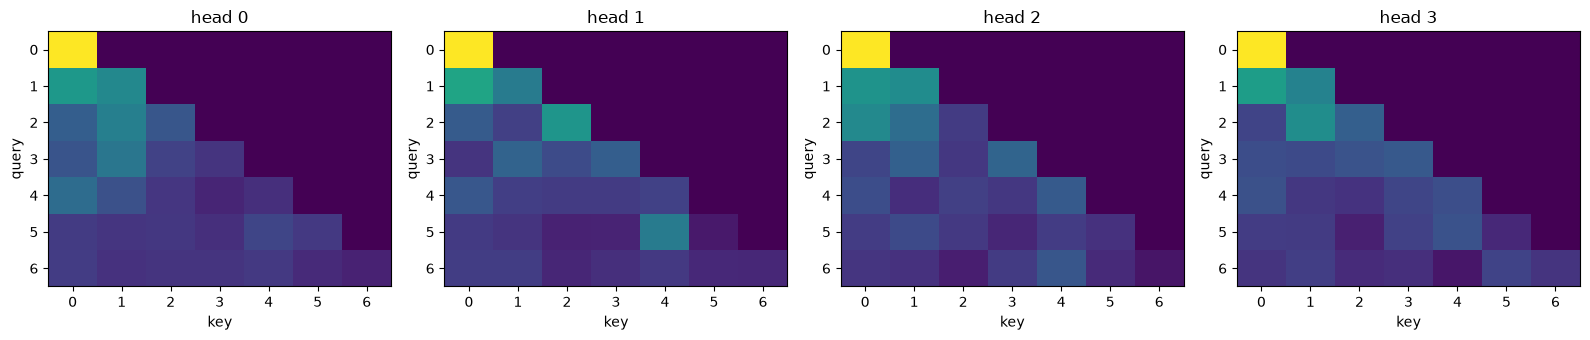

已保存: /home/tachikoma/projects/llm-playground/oss-upgrade/v2-work/outputs/notebooks/attn_layer0_head0.png


In [3]:
import matplotlib.pyplot as plt

from my_llm.utils.viz import plot_attention_heatmap

fig, axes = plt.subplots(1, cfg.n_heads, figsize=(4 * cfg.n_heads, 3.5))
for head in range(cfg.n_heads):
    ax = axes[head]
    ax.imshow(w_masked[head].numpy(), cmap="viridis", aspect="auto")
    ax.set_title(f"head {head}")
    ax.set_xlabel("key")
    ax.set_ylabel("query")
fig.tight_layout()
plt.show()

saved = plot_attention_heatmap(
    w_masked, out_path=ROOT / "outputs" / "notebooks" / "attn_layer0_head0.png", layer=0, head=0
)
print("已保存:", saved)

## 把因果掩码去掉会怎样

左边是正常（有掩码）：第 i 行只能在 0..i 上有值，上三角严格为 0——
否则第 i 个位置就能"偷看"后面的词，语言建模任务的 loss 会失去意义。
右边是无掩码：上三角全是正数。

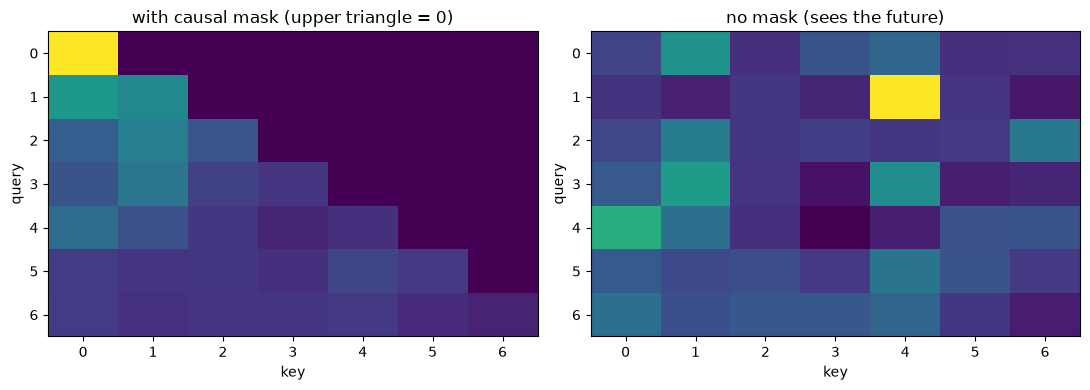

有掩码时上三角最大值: 0.0
无掩码时上三角最大值: 0.3561646342277527


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(w_masked[0].numpy(), cmap="viridis", aspect="auto")
# 图内文字用英文：matplotlib 默认字体（DejaVu Sans）不含 CJK 字形，中文标签会渲染成方块
axes[0].set_title("with causal mask (upper triangle = 0)")
axes[1].imshow(w_unmasked[0].numpy(), cmap="viridis", aspect="auto")
axes[1].set_title("no mask (sees the future)")
for ax in axes:
    ax.set_xlabel("key")
    ax.set_ylabel("query")
fig.tight_layout()
plt.show()

upper = torch.triu(w_masked[0], diagonal=1)
print("有掩码时上三角最大值:", float(upper.abs().max()))
print("无掩码时上三角最大值:", float(torch.triu(w_unmasked[0], diagonal=1).max()))

## 小结

- 掩码用 `torch.finfo(dtype).min` 而不是 `-inf`，并且填在**缩放之后**的分数上（这是 v1 的一个真实 bug）；
- 填 `-inf` 在 fp16 下会产出 NaN，这也是为什么必须避开它；
- 想验证这些权重和 HuggingFace 一致，跑 `pytest -m slow -k attention_weights`。